# Unsupervised Learning 

**Unsupervised learning algorithms** analyze *unlabeled data* to discover hidden patterns, structures, and relationships without human intervention.

# Unsupervised Learning 


We will learn:
1. K-Means Clustering
2. Hierarchical Clustering
3. PCA (Dimensionality Reduction)
4. Anomaly Detection

## Simple idea

**Unsupervised Learning** means we give the model data **without a target/answer column**.

```text
Data (X only)
     ↓
ML Algorithm
     ↓
Find patterns / groups / unusual points
```


## 1. Import Libraries

We use:
- Pandas → create and work with data
- Matplotlib → visualization
- Scikit-learn → machine learning algorithms


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest


# 2. K-Means Clustering

### What is K-Means?

K-Means groups similar data points together.

Example:

> We have customers with Income and Spending Score.

We do **not** tell the model which customer belongs to which group.

We ask it to find **2 groups**.

```text
Customer Data
     ↓
  K-Means
     ↓
Group 1     Group 2
```


In [3]:
data = {
    "Income": [20, 22, 25, 70, 75, 80],
    "Spending": [20, 25, 22, 80, 85, 82]
}

df = pd.DataFrame(data)

df


,Income,Spending
0,20,20
1,22,25
2,25,22
3,70,80
4,75,85
5,80,82


### Select the features

There is **no y / target** here.

We only give the model the data it needs to find groups.


In [4]:
X = df[["Income", "Spending"]]

X


,Income,Spending
0,20,20
1,22,25
2,25,22
3,70,80
4,75,85
5,80,82


### Create the K-Means model

`n_clusters=2` means:

> Create 2 groups.

**`random_state=42` helps us get the same result** when we run the program again.

**`random_state=42` freezes the random choices** so your code behaves the exact same way every single time you run it.



**`n_init=10` tells the computer to try 10 different times** to group your data into clusters, using a new random starting point each time. Once it finishes all 10 tries, it **keeps only the single best result** and throws the rest away.


In [5]:
model = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

model.fit(X)


,n_clusters,2
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


### Get the groups

The model gives each row a cluster number.

- `0` = one group
- `1` = another group

The numbers themselves are just group names.


In [6]:
df["Cluster"] = model.labels_

df


,Income,Spending,Cluster
0,20,20,0
1,22,25,0
2,25,22,0
3,70,80,1
4,75,85,1
5,80,82,1


### Target Audiences

* **Cluster 1**
  * **Profile:** High income / high spending
  * **Strategy:** Luxury promotions and premium services.

* **Cluster 0**
  * **Profile:** Low income / low spending
  * **Strategy:** Budget deals and value-focused discounts.


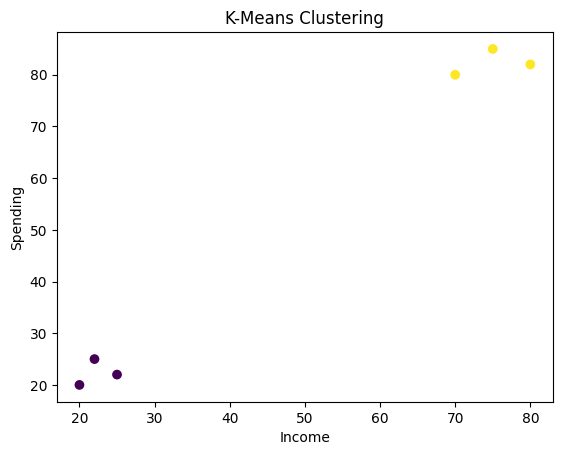

In [7]:
plt.scatter(
    df["Income"],
    df["Spending"],
    c=df["Cluster"]
)

plt.xlabel("Income")
plt.ylabel("Spending")
plt.title("K-Means Clustering")

plt.show()


### K-Means — Remember

> **K-Means is an unsupervised learning algorithm that groups similar data points into K clusters.**

Real-world examples:
- Customer segmentation
- Product grouping
- Student grouping


# 3. Hierarchical Clustering

### What is it?

Hierarchical clustering creates groups step by step.

Simple idea:

```text
A   B   C   D
↓
A-B   C-D
↓
   A-B-C-D
```

It is useful when we want to understand relationships between data points.


In [8]:
data = {
    "Study_Hours": [1, 2, 2, 8, 9, 10],
    "Marks": [35, 40, 45, 80, 85, 90]
}

students = pd.DataFrame(data)

students


,Study_Hours,Marks
0,1,35
1,2,40
2,2,45
3,8,80
4,9,85
5,10,90


In [9]:
X = students[["Study_Hours", "Marks"]]

model = AgglomerativeClustering(
    n_clusters=2
)

students["Cluster"] = model.fit_predict(X)

students


,Study_Hours,Marks,Cluster
0,1,35,1
1,2,40,1
2,2,45,1
3,8,80,0
4,9,85,0
5,10,90,0


### Model Training Process

* **`fit_predict()`**
  * **`fit`** $\rightarrow$ **Learn from data:** The algorithm looks at your data points and figures out where the centers of the groups should be.
  * **`predict`** $\rightarrow$ **Give cluster numbers:** The algorithm assigns a final group label (like `0` or `1`) to each data point.


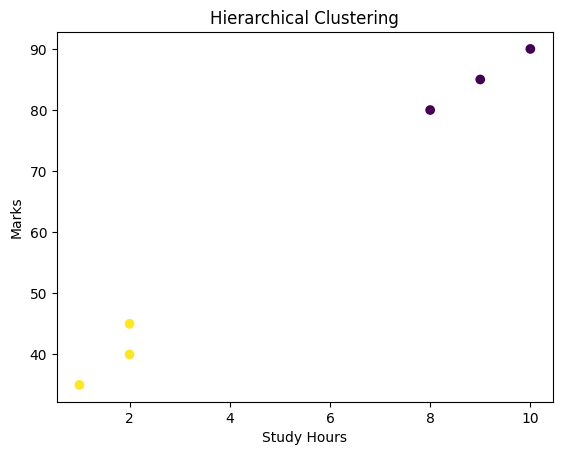

In [10]:
plt.scatter(
    students["Study_Hours"],
    students["Marks"],
    c=students["Cluster"]
)

plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Hierarchical Clustering")

plt.show()


### Hierarchical Clustering — Remember

> **Hierarchical Clustering = Build groups step by step.**

Unlike K-Means, it creates a hierarchy of relationships.


### Types of Clustering Algorithms

* **K-Means Clustering**
  * **Core Concept:** **Find K groups** by picking a fixed number of centers ($K$) and moving them until the data is perfectly grouped.

* **Hierarchical Clustering**
  * **Core Concept:** **Build groups step by step** by either connecting small pieces together into a big tree structure or breaking a big group down into smaller ones.


# 4. PCA — Dimensionality Reduction

### What is PCA?

Imagine we have many features:

```text
Age
Income
Experience
Study Hours
Marks
```

It is difficult to visualize many dimensions.

PCA can reduce:

```text
2 features
    ↓
   PCA
    ↓
1 components
```

The new components are called **PC1**.


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Student data
X = np.array([
    [1, 20],
    [2, 40],
    [3, 60],
    [4, 80],
    [5, 100]
])

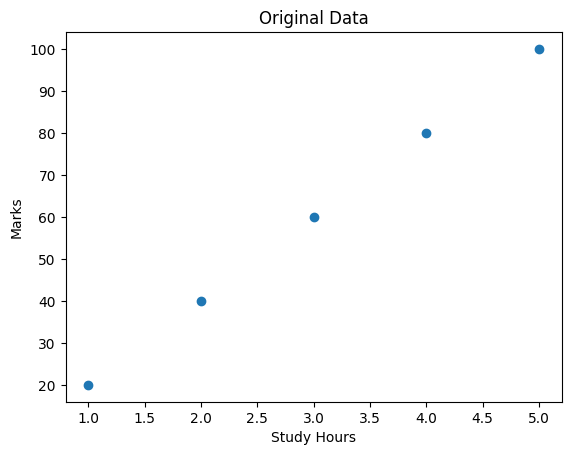

In [29]:
# -------------------------
# Original Data
# -------------------------

plt.scatter(X[:, 0], X[:, 1])

plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Original Data")

plt.show()


In [33]:
# -------------------------
# Apply PCA
# -------------------------

pca = PCA(n_components=1)

X_pca = pca.fit_transform(X)

print("Original Shape:", X.shape)
print("After PCA Shape:", X_pca.shape)
print("\nPCA Result:")
print(X,"\n")
print(X_pca)


Original Shape: (5, 2)
After PCA Shape: (5, 1)

PCA Result:
[[  1  20]
 [  2  40]
 [  3  60]
 [  4  80]
 [  5 100]] 

[[-40.04996879]
 [-20.02498439]
 [  0.        ]
 [ 20.02498439]
 [ 40.04996879]]


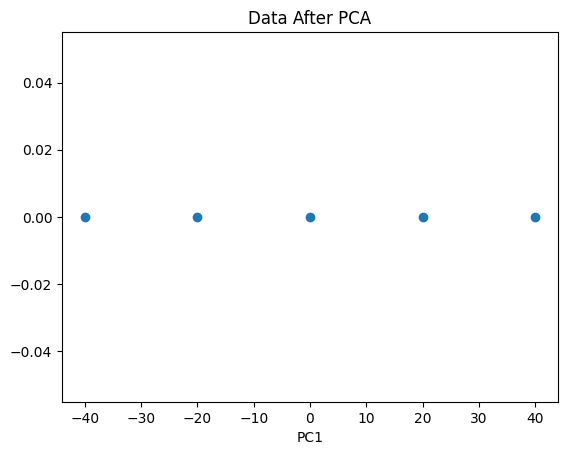

In [32]:

# -------------------------
# PCA Result Visualization
# -------------------------

plt.scatter(X_pca[:, 0], np.zeros(len(X_pca)))

plt.xlabel("PC1")
plt.title("Data After PCA")

plt.show()

### PCA — Remember

> **PCA = Reduce many features into fewer components while keeping as much important information as possible.**

Example:

```text
5 features → PCA → 2 components
```


# 5. Anomaly Detection

### What is an anomaly?

An anomaly is something unusual.

Example:

```text
Study Hours

2
3
4
5
4
3
5
6
4
100  ← unusual
```

We can use **Isolation Forest** to find unusual values.


In [34]:
data = {
    "Study_Hours": [2, 3, 4, 5, 4, 3, 5, 6, 4, 100]
}

data_df = pd.DataFrame(data)

data_df


,Study_Hours
0,2
1,3
2,4
3,5
4,4
5,3
6,5
7,6
8,4
9,100


In [35]:
model = IsolationForest(
    contamination=0.1,
    random_state=42
)

data_df["Result"] = model.fit_predict(
    data_df[["Study_Hours"]]
)

data_df


,Study_Hours,Result
0,2,1
1,3,1
2,4,1
3,5,1
4,4,1
5,3,1
6,5,1
7,6,1
8,4,1
9,100,-1


### Understand the result

Isolation Forest normally gives:

```text
 1  → Normal
-1  → Anomaly
```

So we can find the unusual rows.


In [36]:
anomalies = data_df[data_df["Result"] == -1]

anomalies


,Study_Hours,Result
9,100,-1


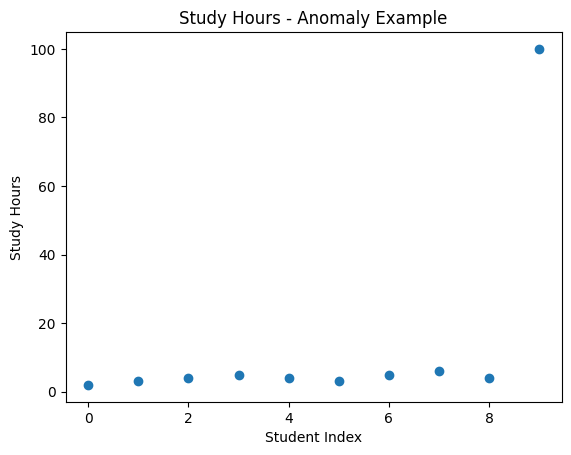

In [37]:
plt.scatter(
    data_df.index,
    data_df["Study_Hours"]
)

plt.xlabel("Student Index")
plt.ylabel("Study Hours")
plt.title("Study Hours - Anomaly Example")

plt.show()


# 6. Quick Comparison

| Algorithm | Simple Meaning | Example |
|---|---|---|
| K-Means | Find groups | Customer segmentation |
| Hierarchical Clustering | Build groups step by step | Student grouping |
| PCA | Reduce many features | 5 features → 2 components |
| Isolation Forest | Find unusual data | Detect unusual study hours |

## Final memory trick

```text
K-Means          → Groups
Hierarchical     → Group hierarchy
PCA              → Reduce dimensions
Anomaly Detection → Find unusual data
```

## Supervised vs Unsupervised

```text
SUPERVISED
X + y
 ↓
Learn
 ↓
Predict


UNSUPERVISED
X only
 ↓
Find patterns
 ↓
Groups / Components / Anomalies
```


Original Shape: (7, 3)
After PCA Shape: (7, 2)


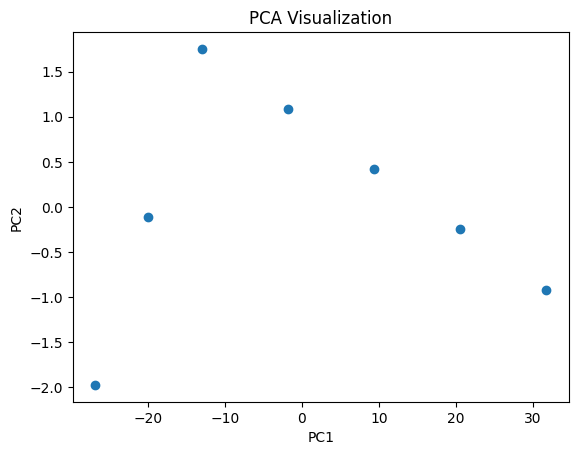

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Student data
X = np.array([
    [1, 40, 60],
    [2, 45, 65],
    [3, 50, 70],
    [4, 60, 75],
    [5, 70, 80],
    [6, 80, 85],
    [7, 90, 90]
])

# PCA: 3 features → 2 components
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print("Original Shape:", X.shape)
print("After PCA Shape:", X_pca.shape)

# Plot PCA result
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1]
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization")

plt.show()